# MIMIC-IV Diagnosis Prediction (Previous Admissions → Next Admission Diagnoses)

This notebook builds a scalable pipeline for:

- Loading **MIMIC-IV** CSVs (excluding prescriptions)
- Creating an **admission-level** table (`grouped_data`) with diagnoses aggregated as a list per `(subject_id, hadm_id)`
- Creating features from **prior admissions** and training a **multi-label neural network** to predict **target admission diagnoses**.

Key design choices for scalability:
- Diagnoses are stored as **sparse matrices (CSR)**, not wide dense columns.
- Targets (`y`) are densified **per-batch only**, so `N × 27k` never becomes a dense array.
- Feature creation avoids `groupby().apply()` over subjects.


In [1]:
import os
import numpy as np
import pandas as pd
import scipy.sparse as sp

import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    hamming_loss, precision_score, recall_score, f1_score, jaccard_score
)

pd.set_option("display.max_columns", 200)


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ---- Update this path ----
DATA_PATH = "/content/drive/MyDrive/capstone_prescription_data/data"

# Sanity check
assert os.path.exists(DATA_PATH), f"DATA_PATH does not exist: {DATA_PATH}"


In [4]:
# -----------------------------
# 1) Load CSVs (skip prescriptions)
# -----------------------------
datasets = {}
for file in os.listdir(DATA_PATH):
    if  "prescriptions" not in file.lower():
        key = file.split(".")[0]
        datasets[key] = pd.read_csv(os.path.join(DATA_PATH, file))

print("Loaded:", sorted(datasets.keys()))


Loaded: ['admissions', 'd_icd_diagnoses', 'd_icd_procedures', 'diagnoses_icd', 'patients']


In [5]:
# -----------------------------
# 2) Build diagnoses table with long_title
# -----------------------------
dx = datasets["diagnoses_icd"][["subject_id", "hadm_id", "icd_code", "icd_version"]].copy()
d_dx = datasets["d_icd_diagnoses"][["icd_code", "icd_version", "long_title"]].copy()

dx = dx.merge(d_dx, how="left", on=["icd_code", "icd_version"])
dx["long_title"] = dx["long_title"].fillna("Unknown")

# recommended: unique diagnoses per admission
dx = dx.drop_duplicates(["subject_id", "hadm_id", "long_title"])

print("Unique diagnosis titles:", dx["long_title"].nunique())
dx.head()


Unique diagnosis titles: 27205


,subject_id,hadm_id,icd_code,icd_version,long_title
0,10000032,22595853,5723,9,Portal hypertension
1,10000032,22595853,78959,9,Other ascites
2,10000032,22595853,5715,9,Cirrhosis of liver without mention of alcohol
3,10000032,22595853,07070,9,Unspecified viral hepatitis C without hepatic ...
4,10000032,22595853,496,9,"Chronic airway obstruction, not elsewhere clas..."


In [6]:
# -----------------------------
# 3) Build admission-level table (one row per hadm)
# -----------------------------
adm = datasets["admissions"].copy()
pat = datasets["patients"][["subject_id", "gender", "anchor_age", "anchor_year", "anchor_year_group"]].copy()

adm["admittime"] = pd.to_datetime(adm["admittime"])
adm["dischtime"] = pd.to_datetime(adm["dischtime"])

adm_keep_cols = [
    "subject_id",
    "hadm_id",
    "admittime",
    "dischtime",
    "admission_type",
    "admit_provider_id",
    "admission_location",
    "discharge_location",
    "insurance",
    "language",
    "marital_status",
    "race",
    "edregtime",
    "edouttime",
]
adm = adm[adm_keep_cols]
adm = adm.merge(pat, how="left", on="subject_id")

adm["edregtime"] = pd.to_datetime(adm["edregtime"], errors="coerce")
adm["edouttime"] = pd.to_datetime(adm["edouttime"], errors="coerce")

adm.head()


,subject_id,hadm_id,admittime,dischtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,gender,anchor_age,anchor_year,anchor_year_group
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,F,52,2180,2014 - 2016
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,EW EMER.,P784FA,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,2180-06-26 15:54:00,2180-06-26 21:31:00,F,52,2180,2014 - 2016
2,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00,EW EMER.,P19UTS,EMERGENCY ROOM,HOSPICE,Medicaid,English,WIDOWED,WHITE,2180-08-05 20:58:00,2180-08-06 01:44:00,F,52,2180,2014 - 2016
3,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,EW EMER.,P06OTX,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,2180-07-23 05:54:00,2180-07-23 14:00:00,F,52,2180,2014 - 2016
4,10000068,25022803,2160-03-03 23:16:00,2160-03-04 06:26:00,EU OBSERVATION,P39NWO,EMERGENCY ROOM,NaN,NaN,English,SINGLE,WHITE,2160-03-03 21:55:00,2160-03-04 06:26:00,F,19,2160,2008 - 2010


In [7]:
# -----------------------------
# 4) Handle missing values / drop high-missing columns
# -----------------------------
# You said these have high missing %; drop if desired:
DROP_COLS = ["edregtime", "edouttime", "discharge_location"]
adm = adm.drop(columns=[c for c in DROP_COLS if c in adm.columns], errors="ignore")

# For remaining categoricals, fill Unknown
for c in adm.columns:
    if adm[c].dtype == "object":
        adm[c] = adm[c].fillna("Unknown")

adm.isnull().mean().sort_values(ascending=False).head(20)


,0
subject_id,0.0
hadm_id,0.0
admittime,0.0
dischtime,0.0
admission_type,0.0
admit_provider_id,0.0
admission_location,0.0
insurance,0.0
language,0.0
marital_status,0.0


In [8]:
# -----------------------------
# 5) Aggregate diagnoses per admission
# -----------------------------
dx_agg = (
    dx.groupby(["subject_id", "hadm_id"], sort=False)["long_title"]
      .apply(list)
      .reset_index()
)

# -----------------------------
# 6) Final grouped_data: one row per admission with diagnosis list
# -----------------------------
grouped_data = adm.merge(dx_agg, how="left", on=["subject_id", "hadm_id"])
grouped_data["long_title"] = grouped_data["long_title"].apply(lambda x: x if isinstance(x, list) else [])

grouped_data = grouped_data.sort_values(["subject_id", "admittime"]).reset_index(drop=True)

print("grouped_data shape:", grouped_data.shape)
print("subjects:", grouped_data["subject_id"].nunique())
grouped_data.head()


grouped_data shape: (546028, 16)
subjects: 223452


,subject_id,hadm_id,admittime,dischtime,admission_type,admit_provider_id,admission_location,insurance,language,marital_status,race,gender,anchor_age,anchor_year,anchor_year_group,long_title
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,URGENT,P49AFC,TRANSFER FROM HOSPITAL,Medicaid,English,WIDOWED,WHITE,F,52,2180,2014 - 2016,"[Portal hypertension, Other ascites, Cirrhosis..."
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,EW EMER.,P784FA,EMERGENCY ROOM,Medicaid,English,WIDOWED,WHITE,F,52,2180,2014 - 2016,[Unspecified viral hepatitis C with hepatic co...
2,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,EW EMER.,P06OTX,EMERGENCY ROOM,Medicaid,English,WIDOWED,WHITE,F,52,2180,2014 - 2016,"[Other iatrogenic hypotension, Chronic hepatit..."
3,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00,EW EMER.,P19UTS,EMERGENCY ROOM,Medicaid,English,WIDOWED,WHITE,F,52,2180,2014 - 2016,[Chronic hepatitis C without mention of hepati...
4,10000068,25022803,2160-03-03 23:16:00,2160-03-04 06:26:00,EU OBSERVATION,P39NWO,EMERGENCY ROOM,Unknown,English,SINGLE,WHITE,F,19,2160,2008 - 2010,"[Alcohol abuse, unspecified]"


In [9]:
# ============================================================
# Utilities for scalable features/labels
# ============================================================
def ensure_list(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    if isinstance(x, str):
        return [x]
    try:
        return list(x)
    except Exception:
        return []

def mode_per_group_counts(prior_df: pd.DataFrame, col: str) -> pd.Series:
    tmp = (prior_df.groupby(["subject_id", col], observed=True)
           .size()
           .rename("n")
           .reset_index())
    if tmp.empty:
        return pd.Series(dtype=object)
    idx = tmp.groupby("subject_id")["n"].idxmax()
    return tmp.loc[idx].set_index("subject_id")[col]

def scipy_csr_to_torch_sparse(csr: sp.csr_matrix) -> torch.Tensor:
    coo = csr.tocoo()
    indices = torch.tensor(np.vstack([coo.row, coo.col]), dtype=torch.long)
    values = torch.tensor(coo.data, dtype=torch.float32)
    shape = torch.Size(coo.shape)
    return torch.sparse_coo_tensor(indices, values, shape).coalesce()

def batched_row_to_dense_targets(y_csr: sp.csr_matrix, rows: np.ndarray, device, use_amp: bool):
    y_batch = y_csr[rows, :].toarray()
    dtype = torch.float16 if (use_amp and device.type == "cuda") else torch.float32
    return torch.tensor(y_batch, device=device, dtype=dtype)

def freq_encode_train_test(X_train: pd.DataFrame, X_test: pd.DataFrame, cat_cols):
    freq_maps = {}
    n = len(X_train)
    for c in cat_cols:
        freqs = (X_train.groupby(c).size() / n)
        freq_maps[c] = freqs
        X_train[c] = X_train[c].map(freqs).fillna(0.0)
        X_test[c]  = X_test[c].map(freqs).fillna(0.0)
    return X_train, X_test, freq_maps


In [10]:
# ============================================================
# Build per-subject features from prior admissions + sparse dx
# ============================================================
def build_features_and_labels(grouped_data: pd.DataFrame):
    df = grouped_data.copy()

    df["admittime"] = pd.to_datetime(df["admittime"])
    df["dischtime"] = pd.to_datetime(df["dischtime"])
    df["number_of_days_stay"] = (df["dischtime"] - df["admittime"]).dt.total_seconds() / 86400.0

    df["long_title"] = df["long_title"].apply(ensure_list)

    # target admission = most recent per subject
    idx_target = df.groupby("subject_id")["admittime"].idxmax()
    target_df = df.loc[idx_target].copy()
    prior_df = df.drop(idx_target).copy()

    # base aggregates from priors (subjects with >=1 prior)
    base = (
        prior_df.groupby("subject_id")
        .agg(
            number_of_prior_admissions=("hadm_id", "nunique"),
            number_of_total_days_stay=("number_of_days_stay", "sum"),
            average_days_per_admission=("number_of_days_stay", "mean"),
            median_days_per_admission=("number_of_days_stay", "median"),
            max_days_per_admission=("number_of_days_stay", "max"),
            min_days_per_admission=("number_of_days_stay", "min"),
            standard_deviation_days_per_admission=("number_of_days_stay", "std"),
        )
    )

    # recent prior admission per subject
    idx_prior_recent = prior_df.groupby("subject_id")["admittime"].idxmax()
    prior_recent = prior_df.loc[idx_prior_recent].set_index("subject_id")

    base["recent_admission_type"] = prior_recent["admission_type"]
    base["recent_admit_provider_id"] = prior_recent["admit_provider_id"]
    base["recent_admission_location"] = prior_recent["admission_location"]
    base["recent_discharge_location"] = prior_recent["discharge_location"] if "discharge_location" in prior_recent.columns else "Unknown"
    base["recent_insurance"] = prior_recent["insurance"]
    base["recent_language"] = prior_recent["language"]
    base["recent_marital_status"] = prior_recent["marital_status"]
    base["recent_number_of_days_stay"] = prior_recent["number_of_days_stay"]
    base["most_recent_race"] = prior_recent["race"]
    base["most_recent_gender"] = prior_recent["gender"]
    base["age"] = prior_recent["anchor_age"]

    # frequent/mode from priors
    base["frequent_admission_type"] = mode_per_group_counts(prior_df, "admission_type")
    base["frequent_admit_provider_id"] = mode_per_group_counts(prior_df, "admit_provider_id")
    base["frequent_admission_location"] = mode_per_group_counts(prior_df, "admission_location")
    if "discharge_location" in prior_df.columns:
        base["frequent_discharge_location"] = mode_per_group_counts(prior_df, "discharge_location")
    base["frequent_insurance"] = mode_per_group_counts(prior_df, "insurance")

    # attach target metadata (optional; you can remove these if you consider leakage)
    target_df = target_df.set_index("subject_id")


    base = base.reset_index()

    # ---- Build sparse X_diag (prior counts) and y (target multi-hot) ----
    prior_dx = prior_df[["subject_id", "long_title"]].explode("long_title").dropna(subset=["long_title"])
    prior_counts = (
        prior_dx.groupby(["subject_id", "long_title"], observed=True)
        .size()
        .rename("cnt")
        .reset_index()
    )

    target_dx = target_df.reset_index()[["subject_id", "long_title"]].explode("long_title").dropna(subset=["long_title"])
    target_dx = target_dx.drop_duplicates(["subject_id", "long_title"])

    diag_vocab = pd.Index(
        pd.concat([prior_counts["long_title"], target_dx["long_title"]], ignore_index=True).unique()
    )
    diag_to_idx = {d: i for i, d in enumerate(diag_vocab)}
    L = len(diag_vocab)
    print(f"Diagnosis vocab size = {L}")

    base_subjects = base["subject_id"].values
    target_subjects = target_dx["subject_id"].unique()
    common = np.intersect1d(base_subjects, target_subjects)

    base = base[base["subject_id"].isin(common)].reset_index(drop=True)
    subj_order = base["subject_id"].values
    subj_to_row = {sid: i for i, sid in enumerate(subj_order)}
    N = len(subj_order)
    print(f"Subjects kept (>=1 prior + has target) = {N}")

    prior_counts = prior_counts[prior_counts["subject_id"].isin(common)]
    row_idx = prior_counts["subject_id"].map(subj_to_row).to_numpy()
    col_idx = prior_counts["long_title"].map(diag_to_idx).to_numpy()
    data = prior_counts["cnt"].astype(np.float32).to_numpy()
    X_diag_csr = sp.csr_matrix((data, (row_idx, col_idx)), shape=(N, L), dtype=np.float32)

    target_dx = target_dx[target_dx["subject_id"].isin(common)]
    y_row = target_dx["subject_id"].map(subj_to_row).to_numpy()
    y_col = target_dx["long_title"].map(diag_to_idx).to_numpy()
    y_data = np.ones(len(target_dx), dtype=np.float32)
    y_csr = sp.csr_matrix((y_data, (y_row, y_col)), shape=(N, L), dtype=np.float32)

    return base, X_diag_csr, y_csr, diag_vocab


In [11]:
class MultiLabelDxNet(nn.Module):
    def __init__(self, tab_in: int, diag_in: int, hidden=[1024, 512, 256], dropout=0.2):
        super().__init__()
        self.diag_proj = nn.Linear(diag_in, hidden[0], bias=True)
        self.tab_proj = nn.Linear(tab_in, hidden[0], bias=True)

        layers = []
        prev = hidden[0]
        for h in hidden[1:]:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.BatchNorm1d(h), nn.Dropout(dropout)]
            prev = h
        self.shared = nn.Sequential(*layers)
        self.out = nn.Linear(prev, diag_in)

    def forward(self, x_tab_dense: torch.Tensor, x_diag_dense: torch.Tensor) -> torch.Tensor:
        diag_emb = self.diag_proj(x_diag_dense)
        tab_emb = self.tab_proj(x_tab_dense)
        x = torch.relu(diag_emb + tab_emb)
        x = self.shared(x)
        return self.out(x)


In [12]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    hamming_loss, precision_score, recall_score, f1_score, jaccard_score
)

# Speed knobs for 3090 (Ampere)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True


def run_training_fast(
    grouped_data,
    batch_size=1024,
    epochs=5,
    lr=1e-3,
    test_size=0.2,
    random_state=42,
    use_pos_weight=True,
    precompute_dense_diag=True,     # << key speedup
):
    # 1) Build features + sparse matrices
    base_df, X_diag_csr, y_csr, diag_vocab = build_features_and_labels(grouped_data)

    X_tab = base_df.drop(columns=["subject_id"]).copy()
    cat_cols = [c for c in X_tab.columns if X_tab[c].dtype == "object"]
    num_cols = [c for c in X_tab.columns if c not in cat_cols]

    idx = np.arange(len(X_tab))
    train_idx, test_idx = train_test_split(idx, test_size=test_size, random_state=random_state)

    X_train_tab = X_tab.iloc[train_idx].copy()
    X_test_tab  = X_tab.iloc[test_idx].copy()

    # 2) Missing values: numeric->median(train), cat->Unknown
    for c in num_cols:
        med = X_train_tab[c].median()
        X_train_tab[c] = X_train_tab[c].fillna(med)
        X_test_tab[c]  = X_test_tab[c].fillna(med)
    for c in cat_cols:
        X_train_tab[c] = X_train_tab[c].fillna("Unknown")
        X_test_tab[c]  = X_test_tab[c].fillna("Unknown")

    # 3) Frequency encoding based on train
    X_train_tab, X_test_tab, _ = freq_encode_train_test(X_train_tab, X_test_tab, cat_cols)

    X_train_tab_np = X_train_tab.values.astype(np.float32)
    X_test_tab_np  = X_test_tab.values.astype(np.float32)

    # 4) Device + AMP
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    use_amp = (device.type == "cuda")

    tab_in = X_train_tab_np.shape[1]
    L = X_diag_csr.shape[1]

    # IMPORTANT: MultiLabelDxNet must accept DENSE x_diag input:
    # forward: diag_emb = self.diag_proj(x_diag_dense)
    model = MultiLabelDxNet(tab_in=tab_in, diag_in=L, hidden=[1024, 512, 256], dropout=0.2)

    # Multi-GPU OK because both inputs are dense tensors
    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)

    model = model.to(device)

    # 5) Loss
    if use_pos_weight:
        pos = np.asarray(y_csr[train_idx, :].sum(axis=0)).ravel()
        neg = len(train_idx) - pos
        pw = neg / (pos + 1e-8)
        pw = np.clip(pw, 1.0, 10.0)   # try 5.0 or 10.0 first
        pos_weight = torch.tensor(pw, dtype=torch.float32, device=device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    else:
        criterion = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    # 6) Move tabular arrays once
    X_train_tab_t = torch.tensor(X_train_tab_np, dtype=torch.float32, device=device)
    X_test_tab_t  = torch.tensor(X_test_tab_np,  dtype=torch.float32, device=device)

    # ============================================================
    # SPEEDUP: precompute dense float16 diagnosis matrix
    # ============================================================
    if precompute_dense_diag:
        # ~20GB if N~364k and L~27k (float16)
        print("Precomputing dense float16 X_diag... (one-time, RAM heavy but fast)")
        X_diag_dense = X_diag_csr.toarray().astype(np.float16)
        # optional: free CSR to save RAM
        # del X_diag_csr
    else:
        X_diag_dense = None

    # ---- TRAIN ----
    loss_history = []
    model.train()
    for epoch in range(1, epochs + 1):
        perm = np.random.permutation(len(train_idx))
        total_loss = 0.0

        for start in range(0, len(perm), batch_size):
            bpos = perm[start:start + batch_size]   # positions within train set
            rows = train_idx[bpos]                  # global rows into diag/label matrices

            x_tab_b = X_train_tab_t[bpos]

            if precompute_dense_diag:
                # FAST slice from dense float16 RAM array
                x_diag_b = torch.tensor(X_diag_dense[rows], device=device, dtype=torch.float16)
            else:
                # slower fallback
                x_diag_b = torch.tensor(X_diag_csr[rows, :].toarray(), dtype=torch.float32, device=device)

            # y always float32
            y_b = torch.tensor(y_csr[rows, :].toarray(), dtype=torch.float32, device=device)

            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=use_amp):
                logits = model(x_tab_b, x_diag_b)
                loss = criterion(logits, y_b)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item() * len(bpos)

        epoch_loss = total_loss / len(train_idx)
        loss_history.append(epoch_loss)
        print(f"Epoch {epoch}/{epochs} | loss={epoch_loss:.6f}")

    # ---- EVAL (fixed indexing) ----
    model.eval()
    preds_list, ytrue_list, probs_list = [], [], []

    test_pos = np.arange(len(test_idx))
    with torch.no_grad():
        for start in range(0, len(test_pos), batch_size):
            bpos = test_pos[start:start + batch_size]   # positions into X_test_tab_t
            rows = test_idx[bpos]                       # global rows into diag/label matrices

            x_tab_b = X_test_tab_t[bpos]

            if precompute_dense_diag:
                x_diag_b = torch.tensor(X_diag_dense[rows], device=device, dtype=torch.float16)
            else:
                x_diag_b = torch.tensor(X_diag_csr[rows, :].toarray(), dtype=torch.float32, device=device)

            with torch.cuda.amp.autocast(enabled=use_amp):
                logits = model(x_tab_b, x_diag_b)
            probs = torch.sigmoid(logits.float())
            preds = (probs > 0.5).float().cpu().numpy()

            y_true = y_csr[rows, :].toarray()
            preds_list.append(preds)
            probs_list.append(probs.cpu().numpy())
            ytrue_list.append(y_true)

    preds = np.vstack(preds_list)
    y_true = np.vstack(ytrue_list)
    probs_all = np.vstack(probs_list)

    metrics = {
        "Hamming Loss":      hamming_loss(y_true, preds),
        "Precision (micro)": precision_score(y_true, preds, average="micro", zero_division=0),
        "Recall (micro)":    recall_score(y_true, preds, average="micro", zero_division=0),
        "F1 (micro)":        f1_score(y_true, preds, average="micro", zero_division=0),
        "Precision (macro)": precision_score(y_true, preds, average="macro", zero_division=0),
        "Recall (macro)":    recall_score(y_true, preds, average="macro", zero_division=0),
        "F1 (macro)":        f1_score(y_true, preds, average="macro", zero_division=0),
        "Jaccard (micro)":   jaccard_score(y_true, preds, average="micro", zero_division=0),
        "Jaccard (macro)":   jaccard_score(y_true, preds, average="macro", zero_division=0),
    }

    # 0.9 + 0.4 = 1.3/2 = 0.65 # Macro
    # 0.9 + 0.4 = 9/10 + 4/10

    for k, v in metrics.items():
        print(f"{k}: {v:.6f}")

    # Return artifacts so you can visualize without retraining
    artifacts = {
        "base_df": base_df,
        "diag_vocab": diag_vocab,
        "X_diag_csr": X_diag_csr,
        "y_csr": y_csr,
        "train_idx": train_idx,
        "test_idx": test_idx,
        "X_test_tab_np": X_test_tab_np,
        "device": device,
        "X_diag_dense": X_diag_dense if precompute_dense_diag else None,
        "loss_history": loss_history,
        "preds": preds,
        "y_true": y_true,
        "probs_all": probs_all,
        "metrics": metrics,
    }

    return model, diag_vocab, artifacts


In [ ]:
model, diag_vocab, artifacts = run_training_fast(
    grouped_data,
    batch_size=2048,   # try 2048 if GPU memory allows
    epochs=200,
    lr=1e-3,
    use_pos_weight=True,
    precompute_dense_diag=True
)


Diagnosis vocab size = 27205
Subjects kept (>=1 prior + has target) = 100101


/tmp/ipykernel_2625/175257464.py:81: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


Precomputing dense float16 X_diag... (one-time, RAM heavy but fast)


/tmp/ipykernel_2625/175257464.py:123: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch 1/200 | loss=0.681482
Epoch 2/200 | loss=0.436340
Epoch 3/200 | loss=0.126544
Epoch 4/200 | loss=0.048819
Epoch 5/200 | loss=0.030436
Epoch 6/200 | loss=0.024679
Epoch 7/200 | loss=0.022779
Epoch 8/200 | loss=0.020192
Epoch 9/200 | loss=0.018963
Epoch 10/200 | loss=0.018467
Epoch 11/200 | loss=0.017707
Epoch 12/200 | loss=0.017278
Epoch 13/200 | loss=0.017016
Epoch 14/200 | loss=0.016872
Epoch 15/200 | loss=0.016711
Epoch 16/200 | loss=0.016508
Epoch 17/200 | loss=0.016249
Epoch 18/200 | loss=0.016121
Epoch 19/200 | loss=0.016210
Epoch 20/200 | loss=0.016017
Epoch 21/200 | loss=0.015945
Epoch 22/200 | loss=0.016253
Epoch 23/200 | loss=0.015781
Epoch 24/200 | loss=0.015650
Epoch 25/200 | loss=0.015476
Epoch 26/200 | loss=0.015468
Epoch 27/200 | loss=0.015286
Epoch 28/200 | loss=0.015128
Epoch 29/200 | loss=0.015000
Epoch 30/200 | loss=0.014920
Epoch 31/200 | loss=0.014785
Epoch 32/200 | loss=0.014694
Epoch 33/200 | loss=0.014587
Epoch 34/200 | loss=0.014483
Epoch 35/200 | loss=0.0

/tmp/ipykernel_2625/175257464.py:154: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Hamming Loss: 0.000906
Precision (micro): 0.200689
Recall (micro): 0.297114
F1 (micro): 0.239563
Precision (macro): 0.007637
Recall (macro): 0.008638
F1 (macro): 0.006707
Jaccard (micro): 0.136081
Jaccard (macro): 0.003851


In [ ]:
import numpy as np

def topk_predictions(probs, k=20):
    idx = np.argpartition(-probs, kth=k-1, axis=1)[:, :k]
    row = np.arange(probs.shape[0])[:, None]
    idx = idx[row, np.argsort(-probs[row, idx], axis=1)]
    pred = np.zeros_like(probs, dtype=np.int8)
    pred[row, idx] = 1
    return pred, idx

def evaluate_topk(y_true, probs, ks=(5, 10, 20, 30)):
    out = {}
    true_counts = y_true.sum(axis=1)

    for k in ks:
        pred, idx = topk_predictions(probs, k=k)

        inter = (pred * y_true).sum(axis=1)
        p_at_k = np.mean(inter / k)
        r_at_k = np.mean(inter / np.maximum(true_counts, 1))
        hits_at_k = np.mean(inter > 0)

        out[k] = {
            "P@K": float(p_at_k),
            "R@K": float(r_at_k),
            "Hits@K": float(hits_at_k),
            "AvgPred": float(pred.sum(axis=1).mean())
        }
    return out

In [ ]:
y_true = artifacts["y_true"]
probs_all = artifacts["probs_all"]

In [ ]:
topk_stats = evaluate_topk(y_true, probs_all, ks=(5, 10, 20, 30))
topk_stats

{5: {'P@K': 0.31775638461112976,
  'R@K': 0.1459597498178482,
  'Hits@K': 0.7299835173068279,
  'AvgPred': 5.0},
 10: {'P@K': 0.2509165406227112,
  'R@K': 0.22034288942813873,
  'Hits@K': 0.8086009689825683,
  'AvgPred': 10.0},
 20: {'P@K': 0.18305030465126038,
  'R@K': 0.3088257312774658,
  'Hits@K': 0.8674891364067729,
  'AvgPred': 20.0},
 30: {'P@K': 0.14753176271915436,
  'R@K': 0.36577263474464417,
  'Hits@K': 0.8952599770241246,
  'AvgPred': 30.0}}

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np
from tqdm import tqdm

def tune_threshold(y_true, probs, thresholds=np.linspace(0.1, 0.95, 18)):
    best = None

    for t in tqdm(thresholds):
        pred = (probs >= t).astype(np.int8)

        micro_f1 = f1_score(y_true, pred, average="micro", zero_division=0)
        micro_p  = precision_score(y_true, pred, average="micro", zero_division=0)
        micro_r  = recall_score(y_true, pred, average="micro", zero_division=0)
        avg_pred = pred.sum(axis=1).mean()

        row = {
            "threshold": float(t),
            "micro_f1": float(micro_f1),
            "micro_precision": float(micro_p),
            "micro_recall": float(micro_r),
            "avg_predicted_labels": float(avg_pred),
        }

        if best is None or row["micro_f1"] > best["micro_f1"]:
            best = row

    return best

In [ ]:
import numpy as np

def tune_threshold_fast(y_true, probs, thresholds=None):
    """
    Fast threshold tuning for multilabel micro metrics.
    y_true: dense numpy array (N, L) with 0/1
    probs: dense numpy array (N, L) with probabilities
    """
    if thresholds is None:
        thresholds = np.linspace(0.1, 0.95, 18)

    y_true_bool = (y_true > 0)
    total_true = y_true_bool.sum()

    results = []
    best = None

    for t in thresholds:
        pred_bool = probs >= t

        tp = np.logical_and(pred_bool, y_true_bool).sum()
        fp = np.logical_and(pred_bool, ~y_true_bool).sum()
        fn = total_true - tp

        precision = tp / (tp + fp + 1e-8)
        recall = tp / (tp + fn + 1e-8)
        f1 = 2 * precision * recall / (precision + recall + 1e-8)
        avg_pred = pred_bool.sum(axis=1).mean()

        row = {
            "threshold": float(t),
            "micro_precision": float(precision),
            "micro_recall": float(recall),
            "micro_f1": float(f1),
            "avg_predicted_labels": float(avg_pred),
        }
        results.append(row)

        if best is None or row["micro_f1"] > best["micro_f1"]:
            best = row

    return best, results

In [ ]:
y_true.shape

(20021, 27205)

In [ ]:
rng = np.random.default_rng(42)
sample_n = min(20021, y_true.shape[0])
rows = rng.choice(y_true.shape[0], size=sample_n, replace=False)

best_thresh_sample, thresh_results_sample = tune_threshold_fast(
    y_true[rows],
    probs_all[rows],
    thresholds=np.linspace(0.1, 0.99, 50)
)
best_thresh_sample

{'threshold': 0.5904081632653061,
 'micro_precision': 0.2438978276077123,
 'micro_recall': 0.24659451069148744,
 'micro_f1': 0.24523875108833662,
 'avg_predicted_labels': 13.208880675290944}

In [ ]:
topk_stats = evaluate_topk(y_true, probs_all, ks=(5, 10, 20, 30))
for k, v in topk_stats.items():
    print(
        f"K={k}: "
        f"P@K={v['P@K']:.4f}, "
        f"R@K={v['R@K']:.4f}, "
        f"Hits@K={v['Hits@K']:.4f}, "
        f"AvgPred={v['AvgPred']:.1f}"
    )

K=5: P@K=0.3178, R@K=0.1460, Hits@K=0.7300, AvgPred=5.0
K=10: P@K=0.2509, R@K=0.2203, Hits@K=0.8086, AvgPred=10.0
K=20: P@K=0.1831, R@K=0.3088, Hits@K=0.8675, AvgPred=20.0
K=30: P@K=0.1475, R@K=0.3658, Hits@K=0.8953, AvgPred=30.0


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.15)

def topk_predictions(probs, k=20):
    idx = np.argpartition(-probs, kth=k-1, axis=1)[:, :k]
    row = np.arange(probs.shape[0])[:, None]
    idx = idx[row, np.argsort(-probs[row, idx], axis=1)]
    pred = np.zeros_like(probs, dtype=np.int8)
    pred[row, idx] = 1
    return pred, idx

def evaluate_topk(y_true, probs, ks=(5, 10, 20, 30)):
    out = {}
    true_counts = y_true.sum(axis=1)

    for k in ks:
        pred, idx = topk_predictions(probs, k=k)
        inter = (pred * y_true).sum(axis=1)

        out[k] = {
            "P@K": float(np.mean(inter / k)),
            "R@K": float(np.mean(inter / np.maximum(true_counts, 1))),
            "Hits@K": float(np.mean(inter > 0)),
            "AvgPred": float(pred.sum(axis=1).mean()),
            "PredMatrix": pred,
            "TopKIdx": idx,
            "CorrectPerPatient": inter,
        }
    return out

ks = (5, 10, 20, 30)
topk_stats = evaluate_topk(y_true, probs_all, ks=ks)

for k in ks:
    print(
        f"K={k}: "
        f"P@K={topk_stats[k]['P@K']:.4f}, "
        f"R@K={topk_stats[k]['R@K']:.4f}, "
        f"Hits@K={topk_stats[k]['Hits@K']:.4f}, "
        f"AvgPred={topk_stats[k]['AvgPred']:.1f}"
    )

K=5: P@K=0.3178, R@K=0.1460, Hits@K=0.7300, AvgPred=5.0
K=10: P@K=0.2509, R@K=0.2203, Hits@K=0.8086, AvgPred=10.0
K=20: P@K=0.1831, R@K=0.3088, Hits@K=0.8675, AvgPred=20.0
K=30: P@K=0.1475, R@K=0.3658, Hits@K=0.8953, AvgPred=30.0


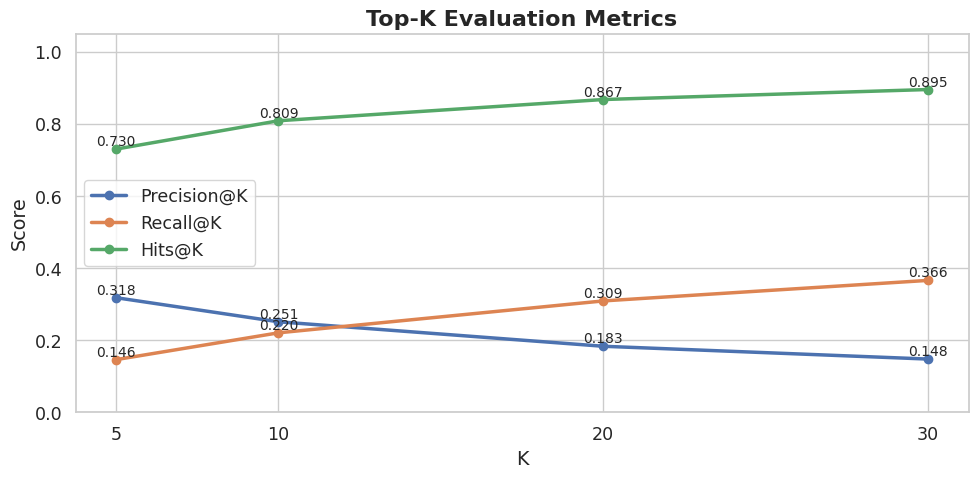

In [ ]:
ks_list = list(ks)
p_at_k = [topk_stats[k]["P@K"] for k in ks_list]
r_at_k = [topk_stats[k]["R@K"] for k in ks_list]
h_at_k = [topk_stats[k]["Hits@K"] for k in ks_list]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ks_list, p_at_k, marker="o", linewidth=2.5, label="Precision@K")
ax.plot(ks_list, r_at_k, marker="o", linewidth=2.5, label="Recall@K")
ax.plot(ks_list, h_at_k, marker="o", linewidth=2.5, label="Hits@K")

for x, y in zip(ks_list, p_at_k):
    ax.text(x, y + 0.01, f"{y:.3f}", ha="center", fontsize=10)
for x, y in zip(ks_list, r_at_k):
    ax.text(x, y + 0.01, f"{y:.3f}", ha="center", fontsize=10)
for x, y in zip(ks_list, h_at_k):
    ax.text(x, y + 0.01, f"{y:.3f}", ha="center", fontsize=10)

ax.set_xlabel("K")
ax.set_ylabel("Score")
ax.set_title("Top-K Evaluation Metrics", fontsize=16, fontweight="bold")
ax.set_xticks(ks_list)
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()

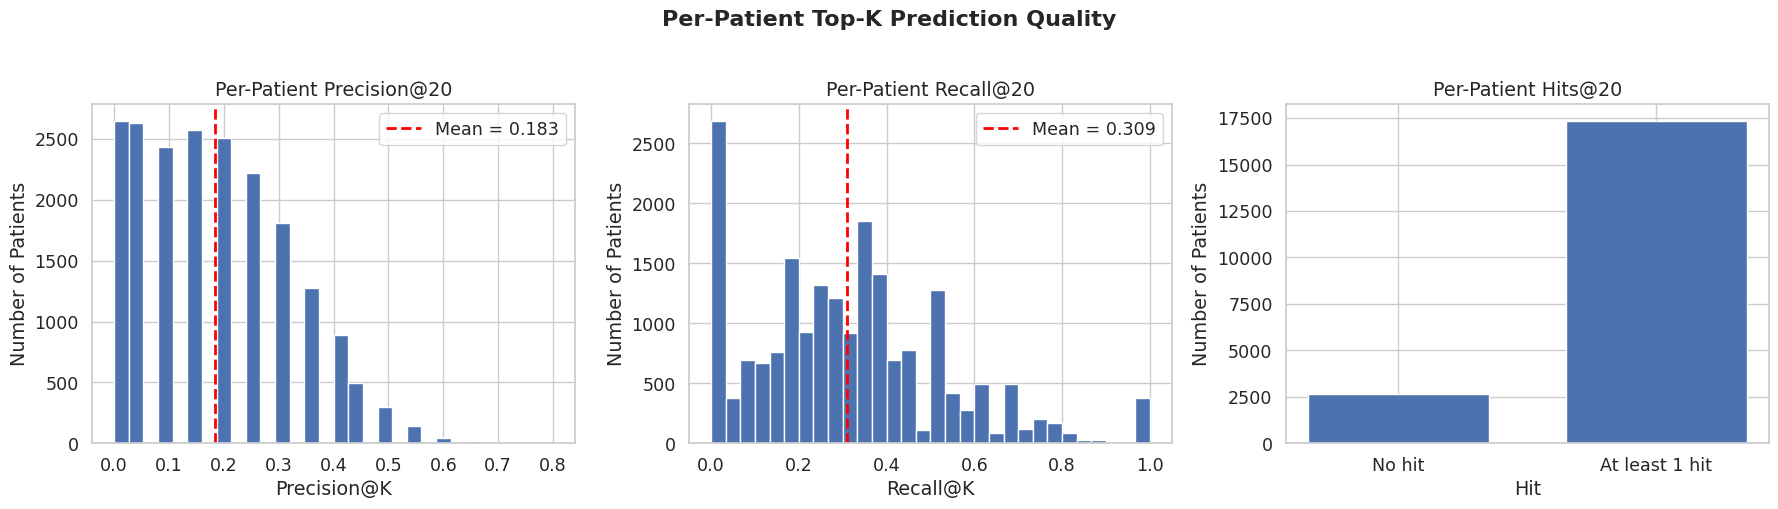

Mean Precision@20: 0.1831
Mean Recall@20:    0.3088
Hits@20:           0.8675


In [ ]:
K_MAIN = 20
pred_topk = topk_stats[K_MAIN]["PredMatrix"]
correct_per_patient = topk_stats[K_MAIN]["CorrectPerPatient"]
n_true_labels = y_true.sum(axis=1)

per_patient_precision_at_k = correct_per_patient / K_MAIN
per_patient_recall_at_k = correct_per_patient / np.maximum(n_true_labels, 1)
per_patient_hit_at_k = (correct_per_patient > 0).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(per_patient_precision_at_k, bins=30, edgecolor="white")
axes[0].axvline(per_patient_precision_at_k.mean(), color="red", linestyle="--", linewidth=2,
                label=f"Mean = {per_patient_precision_at_k.mean():.3f}")
axes[0].set_title(f"Per-Patient Precision@{K_MAIN}")
axes[0].set_xlabel("Precision@K")
axes[0].set_ylabel("Number of Patients")
axes[0].legend()

axes[1].hist(per_patient_recall_at_k, bins=30, edgecolor="white")
axes[1].axvline(per_patient_recall_at_k.mean(), color="red", linestyle="--", linewidth=2,
                label=f"Mean = {per_patient_recall_at_k.mean():.3f}")
axes[1].set_title(f"Per-Patient Recall@{K_MAIN}")
axes[1].set_xlabel("Recall@K")
axes[1].set_ylabel("Number of Patients")
axes[1].legend()

axes[2].hist(per_patient_hit_at_k, bins=np.array([-0.5, 0.5, 1.5]), rwidth=0.7, edgecolor="white")
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(["No hit", "At least 1 hit"])
axes[2].set_title(f"Per-Patient Hits@{K_MAIN}")
axes[2].set_xlabel("Hit")
axes[2].set_ylabel("Number of Patients")

plt.suptitle("Per-Patient Top-K Prediction Quality", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"Mean Precision@{K_MAIN}: {per_patient_precision_at_k.mean():.4f}")
print(f"Mean Recall@{K_MAIN}:    {per_patient_recall_at_k.mean():.4f}")
print(f"Hits@{K_MAIN}:           {per_patient_hit_at_k.mean():.4f}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: actual diagnoses vs correct diagnoses found in top-K
axes[0].scatter(n_true_labels, correct_per_patient, alpha=0.12, s=10)
axes[0].set_xlabel("Actual # of Diagnoses")
axes[0].set_ylabel(f"Correct Diagnoses in Top-{K_MAIN}")
axes[0].set_title(f"Actual Burden vs Correctly Recovered in Top-{K_MAIN}")

# Distribution of correct predictions captured in Top-K
bins = np.arange(0, min(K_MAIN, int(correct_per_patient.max())) + 2) - 0.5
axes[1].hist(correct_per_patient, bins=bins, edgecolor="white")
axes[1].set_xlabel(f"# Correct Diagnoses in Top-{K_MAIN}")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Distribution of Correctly Recovered Diagnoses (Top-{K_MAIN})")

plt.suptitle("Top-K Coverage of True Diagnoses", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"Average true diagnoses per patient: {n_true_labels.mean():.1f}")
print(f"Average correct diagnoses recovered in Top-{K_MAIN}: {correct_per_patient.mean():.2f}")

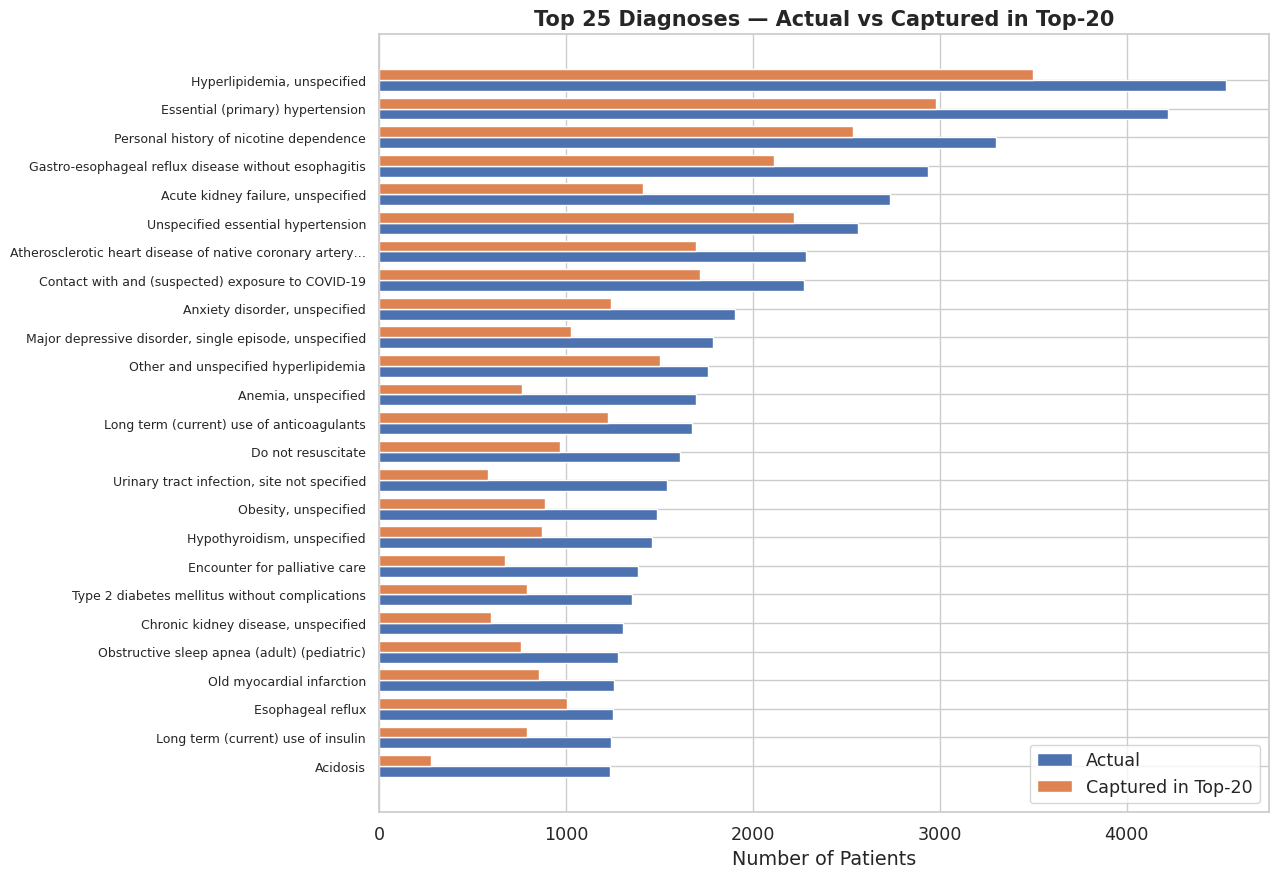

In [ ]:
topk_captured_counts = (pred_topk * y_true).sum(axis=0)   # true positives per diagnosis
actual_counts = y_true.sum(axis=0)

top_k = 25
top_idx = np.argsort(actual_counts)[::-1][:top_k]
top_names = [diag_vocab[i] for i in top_idx]
top_actual = actual_counts[top_idx]
top_captured = topk_captured_counts[top_idx]

short_names = [n[:55] + "…" if len(n) > 55 else n for n in top_names]

y_pos = np.arange(top_k)
bar_w = 0.38

fig, ax = plt.subplots(figsize=(13, 9))
ax.barh(y_pos + bar_w/2, top_actual, height=bar_w, label="Actual", edgecolor="white")
ax.barh(y_pos - bar_w/2, top_captured, height=bar_w, label=f"Captured in Top-{K_MAIN}", edgecolor="white")

ax.set_yticks(y_pos)
ax.set_yticklabels(short_names, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Number of Patients")
ax.set_title(f"Top 25 Diagnoses — Actual vs Captured in Top-{K_MAIN}", fontsize=15, fontweight="bold")
ax.legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_2625/3758190048.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_perf = df_burden.groupby("BurdenGroup").agg({


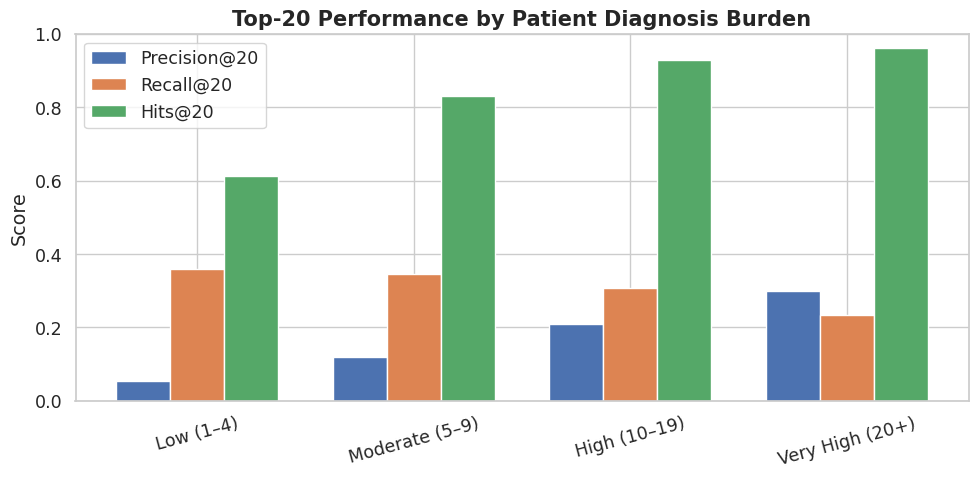

                 Recall@20  Precision@20  Hit@20
BurdenGroup                                     
Low (1–4)           0.3579        0.0531  0.6129
Moderate (5–9)      0.3444        0.1205  0.8309
High (10–19)        0.3062        0.2099  0.9272
Very High (20+)     0.2335        0.2985  0.9601


In [ ]:
burden_bins = pd.cut(
    n_true_labels,
    bins=[0, 5, 10, 20, np.inf],
    labels=["Low (1–4)", "Moderate (5–9)", "High (10–19)", "Very High (20+)"],
    right=False
)

df_burden = pd.DataFrame({
    "BurdenGroup": burden_bins,
    f"Recall@{K_MAIN}": per_patient_recall_at_k,
    f"Precision@{K_MAIN}": per_patient_precision_at_k,
    f"Hit@{K_MAIN}": per_patient_hit_at_k
}).dropna()

group_perf = df_burden.groupby("BurdenGroup").agg({
    f"Recall@{K_MAIN}": "mean",
    f"Precision@{K_MAIN}": "mean",
    f"Hit@{K_MAIN}": "mean"
})

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(group_perf.index))
w = 0.25

ax.bar(x - w, group_perf[f"Precision@{K_MAIN}"], width=w, label=f"Precision@{K_MAIN}")
ax.bar(x,      group_perf[f"Recall@{K_MAIN}"],    width=w, label=f"Recall@{K_MAIN}")
ax.bar(x + w,  group_perf[f"Hit@{K_MAIN}"],       width=w, label=f"Hits@{K_MAIN}")

ax.set_xticks(x)
ax.set_xticklabels(group_perf.index, rotation=15)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Score")
ax.set_title(f"Top-{K_MAIN} Performance by Patient Diagnosis Burden", fontsize=15, fontweight="bold")
ax.legend()

plt.tight_layout()
plt.show()

print(group_perf.round(4))

In [ ]:
captured_counts = (pred_topk * y_true).sum(axis=0)
missed_counts = ((1 - pred_topk) * y_true).sum(axis=0)

top_captured_idx = np.argsort(captured_counts)[::-1][:15]
top_missed_idx = np.argsort(missed_counts)[::-1][:15]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

captured_names = [diag_vocab[i][:45] + ("…" if len(diag_vocab[i]) > 45 else "") for i in top_captured_idx]
axes[0].barh(range(15), captured_counts[top_captured_idx], edgecolor="white")
axes[0].set_yticks(range(15))
axes[0].set_yticklabels(captured_names, fontsize=8.5)
axes[0].invert_yaxis()
axes[0].set_xlabel("# Correct Top-K Captures")
axes[0].set_title(f"Top 15 Diagnoses Most Often Captured in Top-{K_MAIN}",
                  fontsize=12, fontweight="bold")

missed_names = [diag_vocab[i][:45] + ("…" if len(diag_vocab[i]) > 45 else "") for i in top_missed_idx]
axes[1].barh(range(15), missed_counts[top_missed_idx], edgecolor="white")
axes[1].set_yticks(range(15))
axes[1].set_yticklabels(missed_names, fontsize=8.5)
axes[1].invert_yaxis()
axes[1].set_xlabel("# Missed True Diagnoses")
axes[1].set_title(f"Top 15 Diagnoses Most Often Missed from Top-{K_MAIN}",
                  fontsize=12, fontweight="bold")

plt.suptitle("Top-K Quality Audit View", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
actual_in_target = y_true.sum(axis=0)
captured_counts = (pred_topk * y_true).sum(axis=0)

min_support = 50
mask = actual_in_target >= min_support
diag_indices = np.where(mask)[0]

recall_at_k_per_dx = np.zeros(len(diag_vocab), dtype=np.float32)
recall_at_k_per_dx[mask] = captured_counts[mask] / (actual_in_target[mask] + 1e-8)

top_recall_idx = diag_indices[np.argsort(recall_at_k_per_dx[diag_indices])[::-1][:20]]

fig, ax = plt.subplots(figsize=(13, 8))
names = [diag_vocab[i][:55] + ("…" if len(diag_vocab[i]) > 55 else "") for i in top_recall_idx]
recalls = recall_at_k_per_dx[top_recall_idx]
supports = actual_in_target[top_recall_idx].astype(int)

bars = ax.barh(range(len(names)), recalls, edgecolor="white", height=0.7)
ax.set_yticks(range(len(names)))
ax.set_yticklabels([f"{n}  (n={s})" for n, s in zip(names, supports)], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel(f"Recall@{K_MAIN}")
ax.set_xlim(0, 1.05)
ax.set_title(f"Top 20 Diagnoses Best Recovered in Top-{K_MAIN} (≥{min_support} patients)",
             fontsize=14, fontweight="bold")

for bar, val in zip(bars, recalls):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{val:.2f}", va="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

In [ ]:
def show_patient_report_topk(patient_idx_in_test, y_true, probs_all, diag_vocab,
                             base_df, test_idx, k=20, top_n=15):
    global_row = test_idx[patient_idx_in_test]
    subject_id = base_df.iloc[global_row]["subject_id"]

    patient_probs = probs_all[patient_idx_in_test]
    topk_idx = np.argsort(patient_probs)[::-1][:k]
    topn_idx = topk_idx[:top_n]

    true_labels = np.where(y_true[patient_idx_in_test] == 1)[0]
    true_set = set(true_labels)
    topk_set = set(topk_idx)

    correct = true_set & topk_set
    missed = true_set - topk_set

    precision_k = len(correct) / k
    recall_k = len(correct) / max(len(true_set), 1)
    hit_k = int(len(correct) > 0)

    print("=" * 90)
    print(f"PATIENT TOP-{k} REPORT — Subject {int(subject_id)}")
    print(f"Precision@{k}: {precision_k:.3f} | Recall@{k}: {recall_k:.3f} | Hit@{k}: {hit_k}")
    print(f"True Dx: {len(true_set)} | Correct in Top-{k}: {len(correct)} | Missed: {len(missed)}")
    print("=" * 90)

    print(f"\nTop {top_n} ranked predictions")
    print(f"{'#':<4} {'Prob':>7}  {'Status':<12} Diagnosis")
    print("-" * 90)
    for rank, idx in enumerate(topn_idx, 1):
        prob = patient_probs[idx]
        name = diag_vocab[idx]
        status = "✅ Correct" if idx in true_set else "—"
        print(f"{rank:<4} {prob:>7.3f}  {status:<12} {name[:70]}")

    if missed:
        print("\nMissed true diagnoses (not in Top-K):")
        for idx in list(missed)[:10]:
            print(f"  ⚠️  [{patient_probs[idx]:.3f}] {diag_vocab[idx][:70]}")
    print()

In [ ]:
base_df = artifacts["base_df"]
test_idx = artifacts["test_idx"]
diag_vocab = artifacts["diag_vocab"]

In [ ]:
nontrivial = np.where(n_true_labels > 3)[0]
if len(nontrivial) > 0:
    best_idx = nontrivial[np.argmax(per_patient_recall_at_k[nontrivial])]
    median_recall = np.median(per_patient_recall_at_k[nontrivial])
    typical_idx = nontrivial[np.argmin(np.abs(per_patient_recall_at_k[nontrivial] - median_recall))]
    hard_idx = nontrivial[np.argmin(per_patient_recall_at_k[nontrivial])]
else:
    best_idx, typical_idx, hard_idx = 0, len(test_idx)//2, len(test_idx)-1

show_patient_report_topk(best_idx, y_true, probs_all, diag_vocab, base_df, test_idx, k=K_MAIN, top_n=15)
show_patient_report_topk(typical_idx, y_true, probs_all, diag_vocab, base_df, test_idx, k=K_MAIN, top_n=15)
show_patient_report_topk(hard_idx, y_true, probs_all, diag_vocab, base_df, test_idx, k=K_MAIN, top_n=15)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.15)

# Unpack artifacts
loss_history = artifacts["loss_history"]
preds        = artifacts["preds"]
y_true       = artifacts["y_true"]
probs_all    = artifacts["probs_all"]
metrics      = artifacts["metrics"]
diag_vocab   = artifacts["diag_vocab"]
y_csr        = artifacts["y_csr"]
test_idx     = artifacts["test_idx"]
base_df      = artifacts["base_df"]
X_diag_csr   = artifacts["X_diag_csr"]

In [ ]:
# ============================================================
# 1. Training Loss Curve
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(loss_history) + 1), loss_history, linewidth=2, color="#2563eb")
ax.set_xlabel("Epoch")
ax.set_ylabel("BCEWithLogitsLoss (pos-weighted)")
ax.set_title("Training Loss over Epochs", fontsize=16, fontweight="bold")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Annotate start and end
ax.annotate(f"Start: {loss_history[0]:.4f}", xy=(1, loss_history[0]),
            fontsize=10, color="#dc2626", fontweight="bold",
            xytext=(10, 10), textcoords="offset points")
ax.annotate(f"End: {loss_history[-1]:.4f}", xy=(len(loss_history), loss_history[-1]),
            fontsize=10, color="#16a34a", fontweight="bold",
            xytext=(-80, 10), textcoords="offset points")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 2. Overall Evaluation Metrics — Bar Chart
# ============================================================
metric_names = list(metrics.keys())
metric_vals  = list(metrics.values())

# Color: green-ish for "higher is better", red-ish for "lower is better"
colors = ["#ef4444" if "Loss" in n else "#22c55e" for n in metric_names]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(metric_names, metric_vals, color=colors, edgecolor="white", height=0.6)
ax.set_xlim(0, 1.0)
ax.set_xlabel("Score")
ax.set_title("Test-Set Evaluation Metrics", fontsize=16, fontweight="bold")

for bar, val in zip(bars, metric_vals):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 3. Prediction Probability Distribution
# ============================================================
# Sample up to 5M probabilities to keep the histogram fast
flat_probs = probs_all.ravel()
rng = np.random.default_rng(42)
if len(flat_probs) > 5_000_000:
    sample_probs = rng.choice(flat_probs, size=5_000_000, replace=False)
else:
    sample_probs = flat_probs

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution (log scale)
axes[0].hist(sample_probs, bins=200, color="#6366f1", edgecolor="none", log=True)
axes[0].axvline(0.5, color="#dc2626", linestyle="--", linewidth=2, label="Threshold = 0.5")
axes[0].set_xlabel("Predicted Probability")
axes[0].set_ylabel("Count (log)")
axes[0].set_title("All Predicted Probabilities")
axes[0].legend()

# Zoom into 0.1–1.0 range to see positive predictions
high_probs = sample_probs[sample_probs > 0.1]
axes[1].hist(high_probs, bins=100, color="#f59e0b", edgecolor="none")
axes[1].axvline(0.5, color="#dc2626", linestyle="--", linewidth=2, label="Threshold = 0.5")
axes[1].set_xlabel("Predicted Probability")
axes[1].set_ylabel("Count")
axes[1].set_title("Predicted Probabilities > 0.1 (zoom)")
axes[1].legend()

plt.suptitle("Model Confidence Distribution", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()